# Простейшие операции с изображениями с использованием Open CV. Поиск объекта на цветном изображении

In [106]:
import cv2 # импорт Open CV
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [107]:
# считываем данные графических файлой в переменные
bus = cv2.cvtColor(cv2.imread('bus.jpg'), cv2.COLOR_BGR2RGB)
car = cv2.cvtColor(cv2.imread('car.jpg'), cv2.COLOR_BGR2RGB)
fox = cv2.cvtColor(cv2.imread('fox.jpg'), cv2.COLOR_BGR2RGB)
tennis_ball = cv2.cvtColor(cv2.imread('tennis_ball.jpg'), cv2.COLOR_BGR2RGB)
aivazovsky = np.array(Image.open('Айвазовский.jpg')) # считываем через PIL из-за проблемы с расширением файла
horse = np.array(Image.open('лошадь.jpg')) # считываем через PIL из-за проблемы с расширением файла

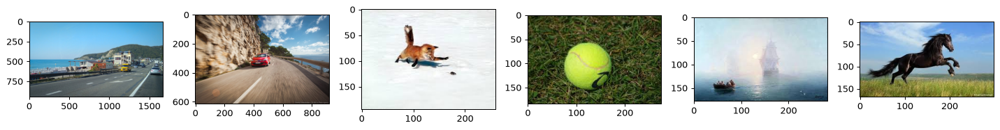

In [108]:
plt.figure(figsize=(16,13), dpi=90)
plt.subplot(1,6,1); plt.imshow(bus)
plt.subplot(1,6,2); plt.imshow(car)
plt.subplot(1,6,3); plt.imshow(fox)
plt.subplot(1,6,4); plt.imshow(tennis_ball)
plt.subplot(1,6,5); plt.imshow(aivazovsky)
plt.subplot(1,6,6); plt.imshow(horse)
plt.tight_layout()
plt.show()

#### 1. Получение полутоновых изображений

In [109]:
# получaем полутоновое изображение
bus_gray = cv2.cvtColor(bus, cv2.COLOR_RGB2GRAY)
car_gray = cv2.cvtColor(car, cv2.COLOR_RGB2GRAY)
fox_gray = cv2.cvtColor(fox, cv2.COLOR_RGB2GRAY)
tennis_ball_gray = cv2.cvtColor(tennis_ball, cv2.COLOR_RGB2GRAY)
aivazovsky_gray = cv2.cvtColor(aivazovsky, cv2.COLOR_RGB2GRAY)
horse_gray = cv2.cvtColor(horse, cv2.COLOR_RGB2GRAY)

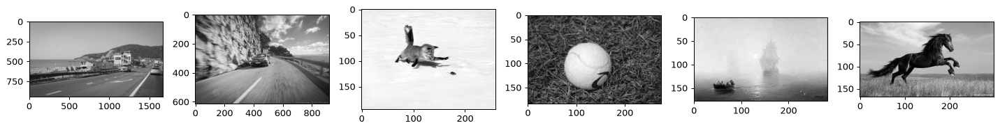

In [110]:
plt.figure(figsize=(16,13), dpi=90)
plt.subplot(1,6,1); plt.imshow(bus_gray, cmap='gray')
plt.subplot(1,6,2); plt.imshow(car_gray, cmap='gray')
plt.subplot(1,6,3); plt.imshow(fox_gray, cmap='gray')
plt.subplot(1,6,4); plt.imshow(tennis_ball_gray, cmap='gray')
plt.subplot(1,6,5); plt.imshow(aivazovsky_gray, cmap='gray')
plt.subplot(1,6,6); plt.imshow(horse_gray, cmap='gray')
plt.tight_layout()
plt.show()

#### 3. Получение изображений высотой в 400 пикселей

In [ ]:
def resize_400(img, height=400):
    # нам надо сохранить соотношение сторон, чтобы изображение не исказилось при изменении размера
    # для этого рассчитаем коэффициент res_img
    print(f'Размер исходного изображения: {img.shape[1]}:{img.shape[0]}')
    res_img = float(height) / img.shape[0]
    dim = (int(img.shape[1] * res_img), height)

    # выбираем интерполяцию в зависимости от res_img
    if res_img <= 1:
        interpolation = cv2.INTER_AREA # из документации open_cv, при уменьшенни лучше INTER_AREA
        print('Выбарана интерполяция: cv2.INTER_AREA')
    else:
        interpolation = cv2.INTER_CUBIC # из документации open_cv, при увеличении лучше INTER_CUBIC
        print('Выбарана интерполяция: cv2.INTER_CUBIC')

    # уменьшаем изображение до подготовленных размеров
    resized = cv2.resize(img, dim, interpolation = interpolation)
    print(f'Размер отскейленного изображения: {resized.shape[1]}:{resized.shape[0]}')
    plt.imshow(resized)

Размер исходного изображения: 1672:941
Выбарана интерполяция: cv2.INTER_AREA
Размер отскейленного изображения: 710:400


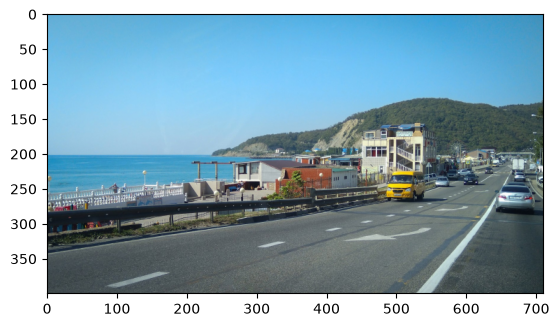

In [ ]:
resize_400(bus)

Размер исходного изображения: 918:612
Выбарана интерполяция: cv2.INTER_AREA
Размер отскейленного изображения: 600:400


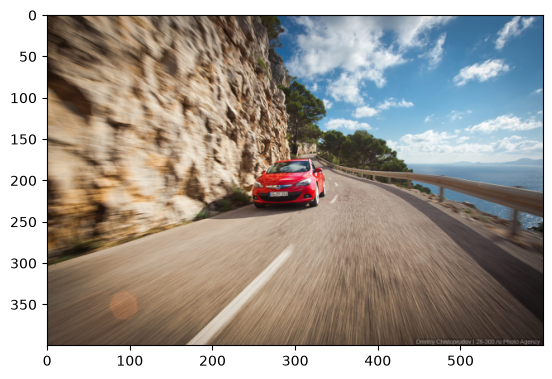

In [ ]:
resize_400(car)

Размер исходного изображения: 259:194
Выбарана интерполяция: cv2.INTER_CUBIC
Размер отскейленного изображения: 534:400


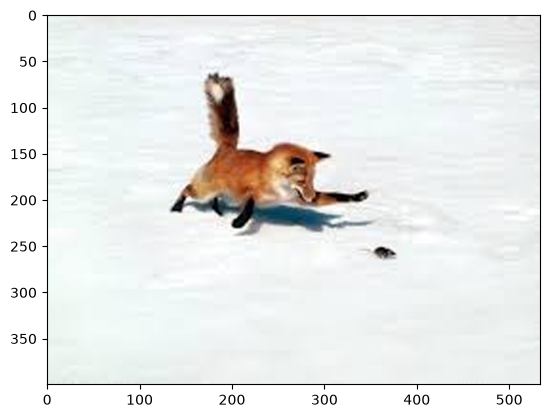

In [ ]:
resize_400(fox)

Размер исходного изображения: 276:183
Выбарана интерполяция: cv2.INTER_CUBIC
Размер отскейленного изображения: 603:400


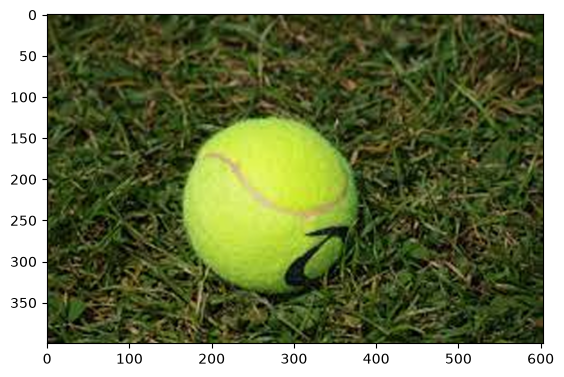

In [ ]:
resize_400(tennis_ball)

Размер исходного изображения: 283:178
Выбарана интерполяция: cv2.INTER_CUBIC
Размер отскейленного изображения: 635:400


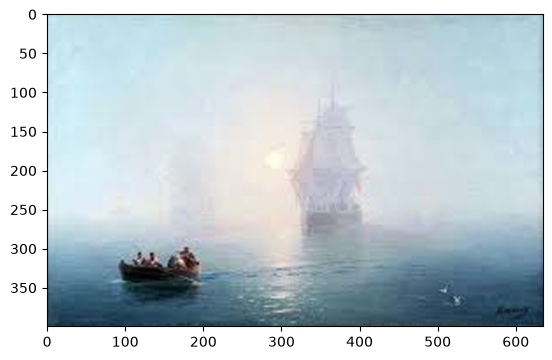

In [ ]:
resize_400(aivazovsky)

Размер исходного изображения: 299:168
Выбарана интерполяция: cv2.INTER_CUBIC
Размер отскейленного изображения: 711:400


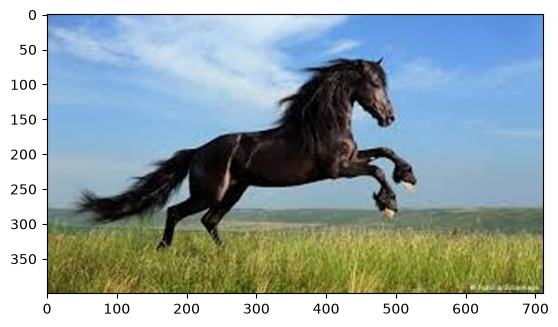

In [ ]:
resize_400(horse)

#### 3. Получение повернутых изображений

In [118]:
def rotate(img):
    (h, w) = img.shape[:2]
    center = (w / 2, h / 2)

    # повернем изображение на 180 градусов
    M = cv2.getRotationMatrix2D(center, 180, 1)
    rotated180 = cv2.warpAffine(img, M, (w, h))
    # повернем изображение на 90 градусов
    M = cv2.getRotationMatrix2D(center, 90, 1)
    rotated90 = cv2.warpAffine(img, M, (w, h))
    plt.figure(figsize=(16,13), dpi=90)
    plt.subplot(1,3,1); plt.imshow(img); plt.title('Исходное изображение')
    plt.subplot(1,3,2); plt.imshow(rotated180); plt.title('180')
    plt.subplot(1,3,3); plt.imshow(rotated90); plt.title('90')
    plt.tight_layout()
    plt.show()

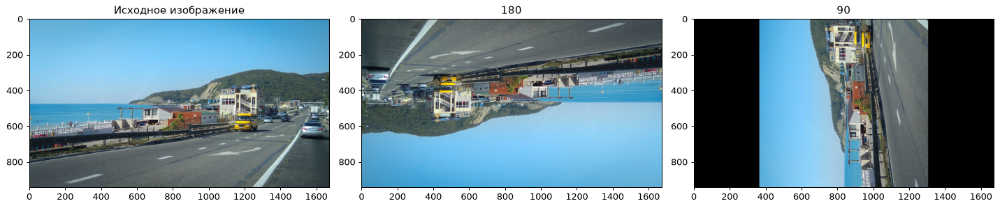

In [119]:
rotate(bus)

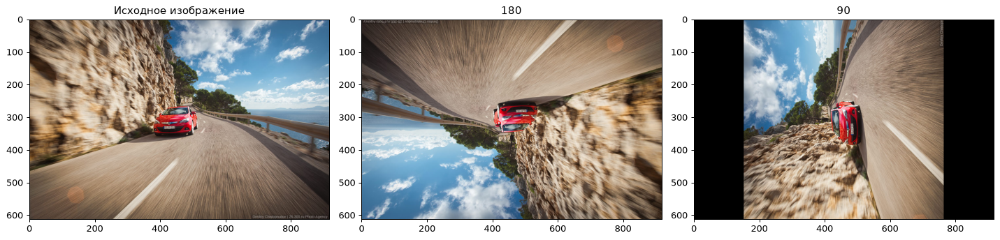

In [120]:
rotate(car)

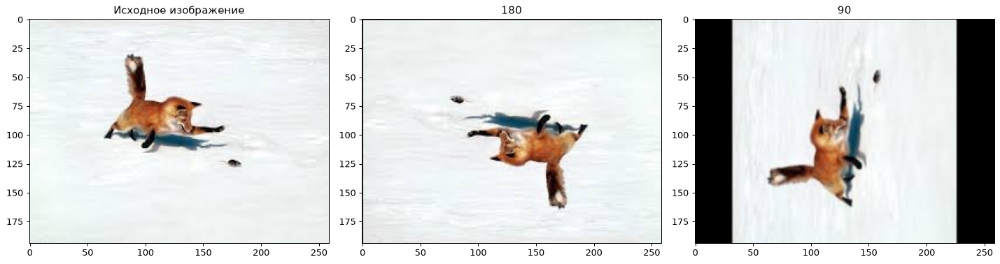

In [121]:
rotate(fox)

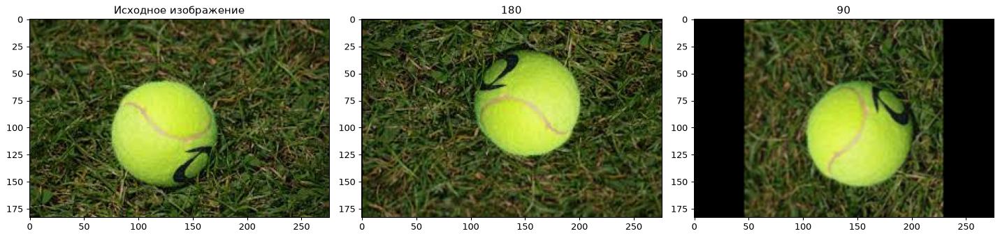

In [122]:
rotate(tennis_ball)

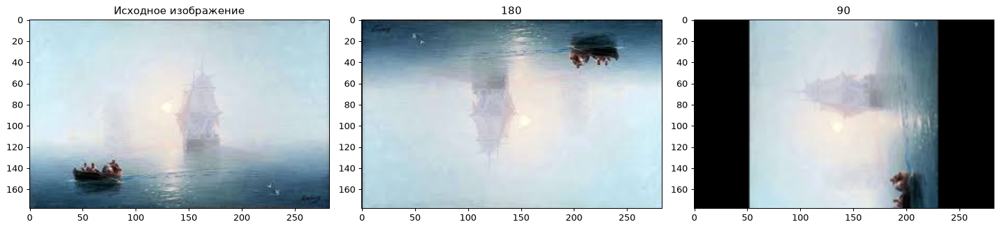

In [123]:
rotate(aivazovsky)

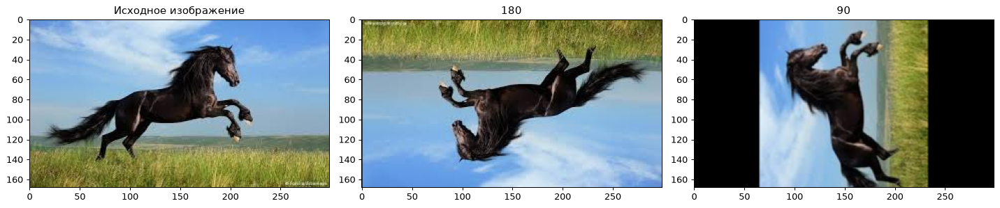

In [124]:
rotate(horse)

#### 4. Получение отраженных изображений

In [ ]:
# функция для отражения изображения по осям
def flip(img):
    plt.figure(figsize=(16,13), dpi=90)
    plt.subplot(1,3,1); plt.imshow(img); plt.title('Исходное изображение')
    plt.subplot(1,3,2); plt.imshow(cv2.flip(img, 1)); plt.title('Отраженное по горизонтали')
    plt.subplot(1,3,3); plt.imshow(cv2.flip(img, 0)); plt.title('Отраженное по вертикали')
    plt.tight_layout()
    plt.show()

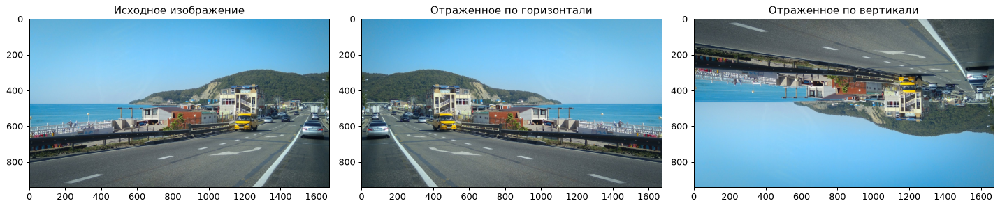

In [126]:
flip(bus)

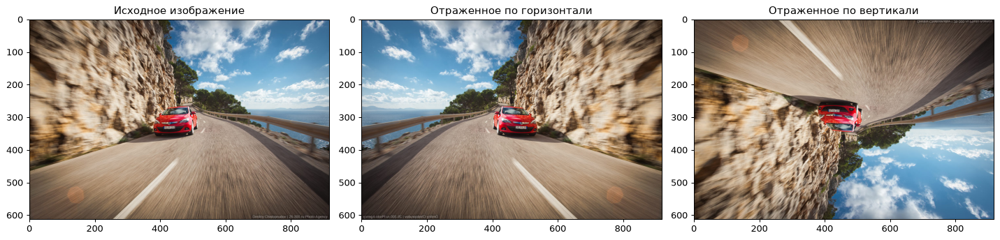

In [127]:
flip(car)

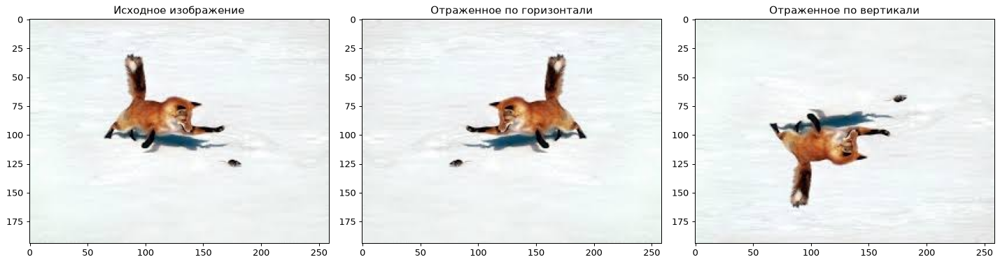

In [128]:
flip(fox)

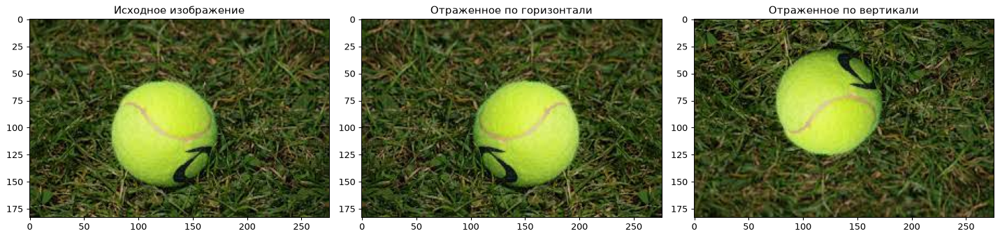

In [129]:
flip(tennis_ball)

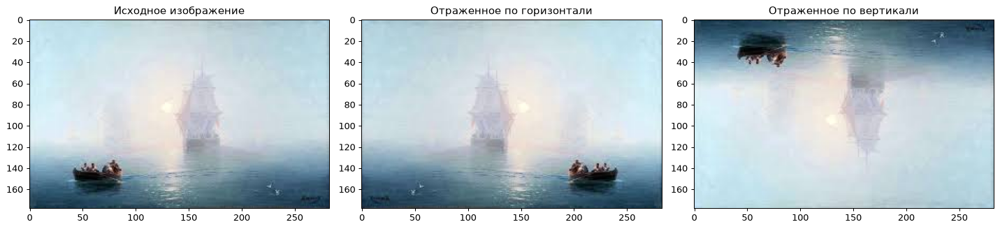

In [130]:
flip(aivazovsky)

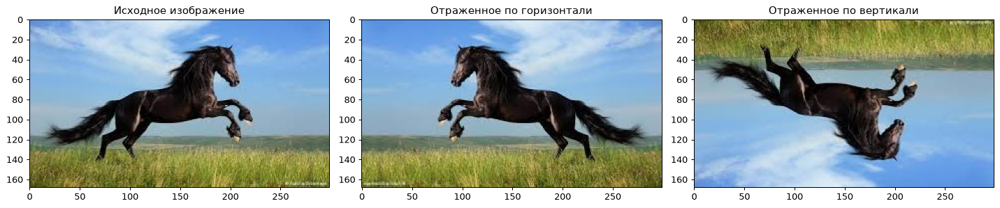

In [131]:
flip(horse)

## Поиск объекта на изображении

In [ ]:
# функция для поиска объекта
def select_object(img_rgb, color_low, color_high, text, font_scale=1, color=(255,255,255)):
    object = cv2.inRange(cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV), color_low, color_high) # переводи в HSV
    moments = cv2.moments(object, 1) # получаем моменты
    x_moment = moments['m10']
    y_moment = moments['m01']
    area = moments['m00']
    # получаем координаты x, y для надписи
    x = int(x_moment / area)
    y = int(y_moment / area)
    plt.figure(figsize=(16,13), dpi=90)
    plt.subplot(1,3,1); plt.imshow(img_rgb); plt.title('Исходное изображение')
    plt.subplot(1,3,2); plt.imshow(object, cmap='gray'); plt.title('Выделенный объект')
    cv2.putText(img_rgb, text, (x, y), cv2.FONT_HERSHEY_SIMPLEX, font_scale, color, 2) # накладываем текст
    plt.subplot(1,3,3); plt.imshow(img_rgb, cmap='gray'); plt.title('Подписанный объект')
    plt.tight_layout()
    plt.show()

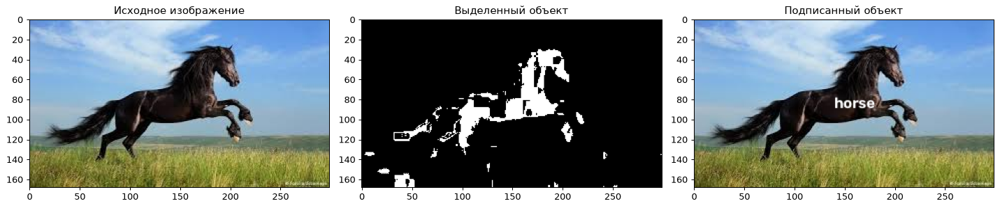

In [133]:
select_object(horse, (0, 0, 0), (25, 255, 255), 'horse', 0.5)

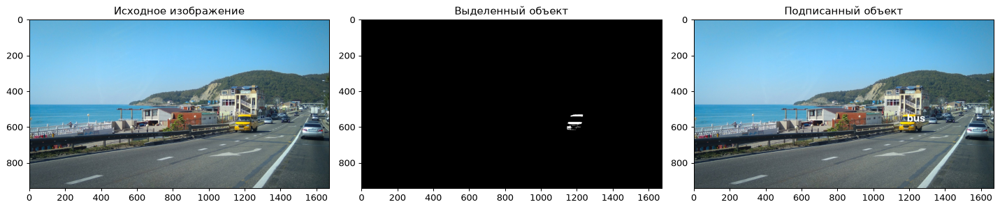

In [134]:
select_object(bus, (9, 144, 210), (31, 255, 255), 'bus', 2)

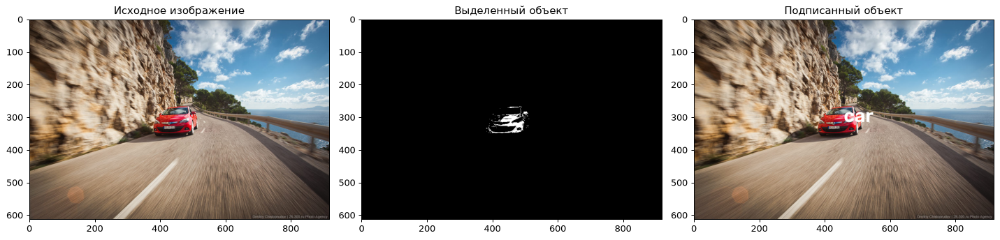

In [135]:
select_object(car, (118, 87, 65), (179, 255, 255), 'car', 2)

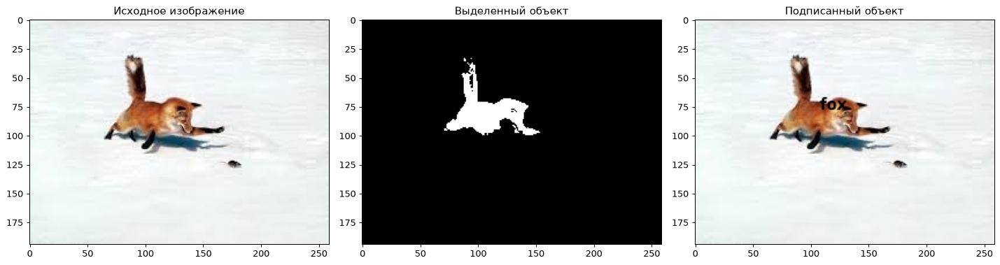

In [136]:
select_object(fox, (0, 92, 26), (26, 255, 255), 'fox', 0.5, (0, 0, 0))

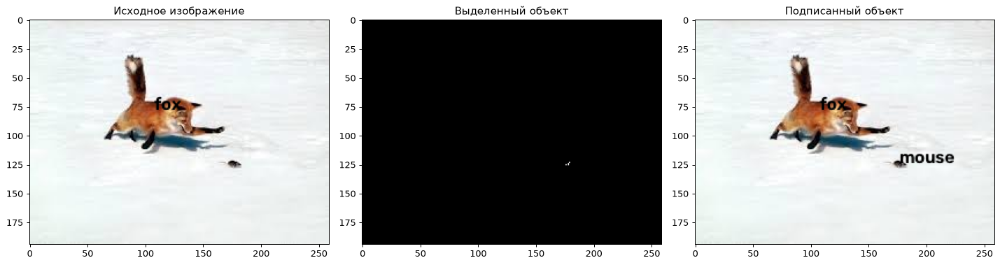

In [137]:
select_object(fox, (151, 0, 26), (179, 72, 51), 'mouse', 0.5, (0, 0, 0))

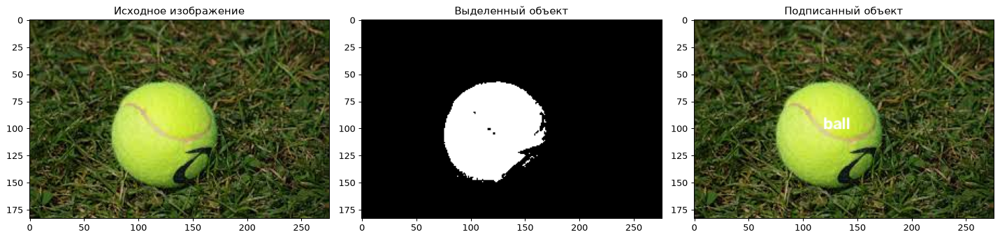

In [138]:
select_object(tennis_ball, (10, 80, 162), (52, 254, 255), 'ball', 0.5)

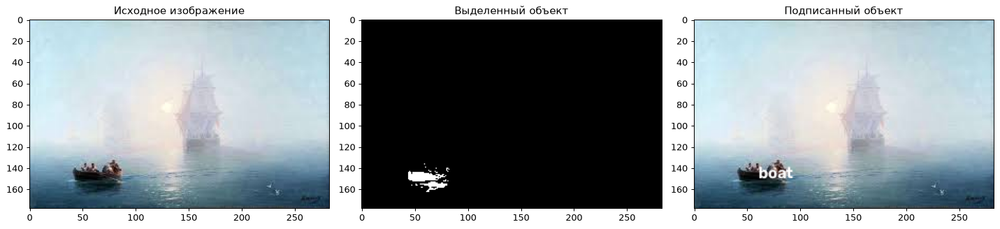

In [139]:
select_object(aivazovsky, (0, 0, 0), (179, 255, 42), 'boat', 0.5)